# Food Delivery ETA Prediction

Case study: predict delivery time (minutes) for a food delivery order using
order-time signals (distance, traffic, weather, delivery partner info, time
of day). Dataset: Kaggle "Food Delivery Dataset" (gauravmalik26), 45,593 rows,
India-based, March 2022.

Notebook follows: EDA -> cleaning -> feature engineering -> leakage review ->
split -> baseline -> model comparison -> evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 30)
sns.set_style('whitegrid')

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FIG_DIR = REPO_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load raw data

In [2]:
df_raw = pd.read_csv(REPO_ROOT / 'data' / 'raw' / 'food_delivery_train.csv')
print(df_raw.shape)
df_raw.head(3)

(45593, 20)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26


In [3]:
df_raw.dtypes

ID                                 str
Delivery_person_ID                 str
Delivery_person_Age                str
Delivery_person_Ratings            str
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                         str
Time_Orderd                        str
Time_Order_picked                  str
Weatherconditions                  str
Road_traffic_density               str
Vehicle_condition                int64
Type_of_order                      str
Type_of_vehicle                    str
multiple_deliveries                str
Festival                           str
City                               str
Time_taken(min)                    str
dtype: object

Columns are almost all read in as strings even where they look numeric
(`Delivery_person_Age`, `Delivery_person_Ratings`, `multiple_deliveries`).
That's the first sign this is genuinely raw, unprocessed data -- worth
checking why before doing anything else.

In [4]:
# sample a few rows raw to see what's actually in the string columns
df_raw[['Delivery_person_Age', 'Delivery_person_Ratings', 'Road_traffic_density',
        'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)']].sample(8, random_state=RANDOM_STATE)

,Delivery_person_Age,Delivery_person_Ratings,Road_traffic_density,multiple_deliveries,Festival,City,Time_taken(min)
7725,30,5,Medium,0,Yes,Metropolitian,(min) 44
949,31,4.7,Jam,2,No,Metropolitian,(min) 41
44893,35,3.6,Jam,0,No,Metropolitian,(min) 39
42071,35,4.6,Medium,2,No,Metropolitian,(min) 38
27091,20,4.6,Jam,NaN,No,Metropolitian,(min) 38
18398,22,4.4,Low,1,No,Metropolitian,(min) 22
13996,28,4.8,Jam,0,No,Metropolitian,(min) 14
10192,20,4.3,Low,1,No,Metropolitian,(min) 17


So the columns are strings because of: trailing whitespace on every
category (`'Urban '`, `'High '`), a literal string `'NaN '` used instead of
an actual missing value, and a `'(min) '` prefix baked into the target
column. None of this is a data quality issue *we* introduced -- it's how the
CSV ships. Cleaning this up is step 4; for now we just need the target
parsed so we can look at its distribution.

## 2. EDA\n\n### 2.1 Target distribution

In [5]:
# parse target: strip '(min) ' prefix and cast to int, just for EDA purposes
# (this exact parsing is repeated properly in the cleaning step)
target_preview = df_raw['Time_taken(min)'].str.replace('(min) ', '', regex=False).astype(int)

print(target_preview.describe())
print('skew:', target_preview.skew().round(3))

count    45593.000000
mean        26.294607
std          9.383806
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64
skew: 0.486


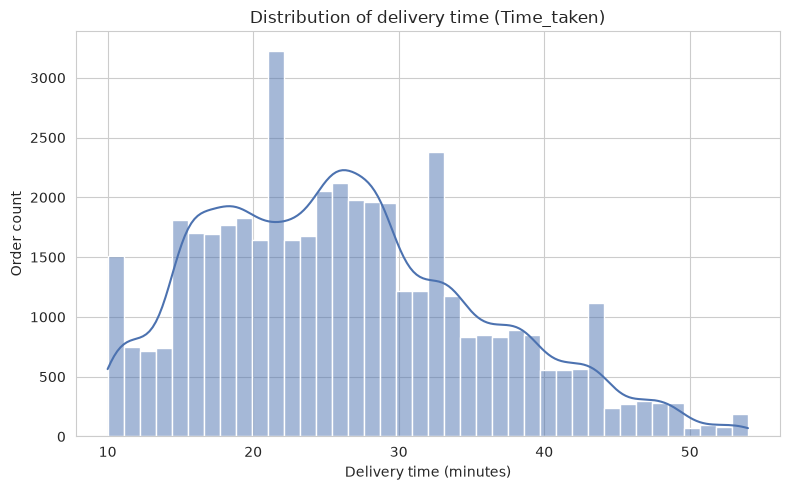

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(target_preview, bins=40, kde=True, ax=ax, color='#4C72B0')
ax.set_xlabel('Delivery time (minutes)')
ax.set_ylabel('Order count')
ax.set_title('Distribution of delivery time (Time_taken)')
fig.tight_layout()
fig.savefig(FIG_DIR / '01_target_distribution.png', dpi=120)
plt.show()

Mean delivery time is in the mid-20s minutes with a right tail out past
50 minutes -- typical for a delivery-time target, not symmetric. Nothing
here looks like a data entry error (no negative times, no absurd 300+ minute
outliers), so no target trimming needed at this stage.

### 2.2 Missingness

In [7]:
# the literal string 'NaN' (with surrounding whitespace) is how missing
# values are encoded in this file, across several columns. Convert those to
# real NaN (on a copy) purely to measure missingness for this EDA section.
obj_cols = df_raw.select_dtypes(include=['object', 'str']).columns
missing_check = df_raw[obj_cols].apply(lambda s: s.str.strip())
missing_check = missing_check.replace('NaN', np.nan)

missing_pct = (missing_check.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print(missing_pct.round(2))

Delivery_person_Ratings    4.18
Delivery_person_Age        4.07
Time_Orderd                3.80
City                       2.63
multiple_deliveries        2.18
Road_traffic_density       1.32
Festival                   0.50
dtype: float64


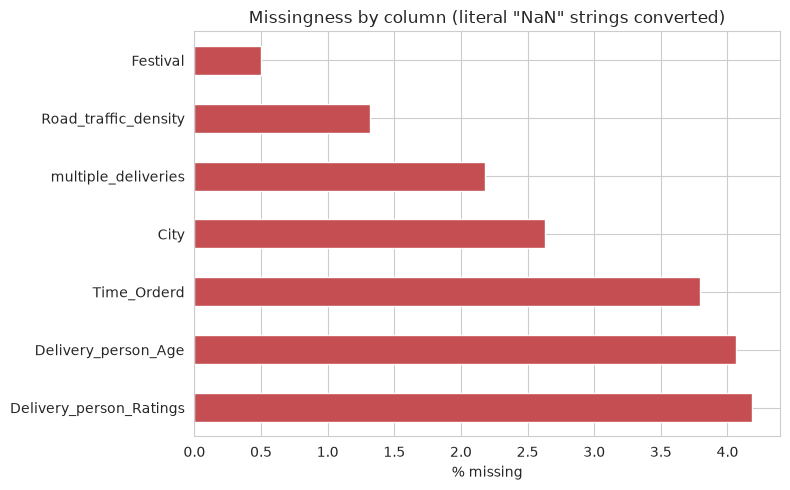

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
missing_pct.plot(kind='barh', ax=ax, color='#C44E52')
ax.set_xlabel('% missing')
ax.set_title('Missingness by column (literal "NaN" strings converted)')
fig.tight_layout()
fig.savefig(FIG_DIR / '02_missingness.png', dpi=120)
plt.show()

Missingness tops out around 4% per column and hits a handful of
different columns (weather, traffic, city, multiple_deliveries, ratings,
age) rather than being concentrated in one place -- this looks like
random operational gaps (sensor/app didn't report that field for that
order) rather than a systematic missing-not-at-random pattern tied to the
target. That supports simple imputation over dropping rows in step 4.

### 2.3 Outliers and invalid values

In [9]:
coord_cols = ['Restaurant_latitude', 'Restaurant_longitude',
              'Delivery_location_latitude', 'Delivery_location_longitude']
print(df_raw[coord_cols].describe())

       Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
count         45593.000000          45593.000000                45593.000000   
mean             17.017729             70.231332                   17.465186   
std               8.185109             22.883647                    7.335122   
min             -30.905562            -88.366217                    0.010000   
25%              12.933284             73.170000                   12.988453   
50%              18.546947             75.898497                   18.633934   
75%              22.728163             78.044095                   22.785049   
max              30.914057             88.433452                   31.054057   

       Delivery_location_longitude  
count                 45593.000000  
mean                     70.845702  
std                      21.118812  
min                       0.010000  
25%                      73.280000  
50%                      76.002574  
75%                 

India's mainland spans roughly 6 to 38 N and 68 to 98 E. Any restaurant
or delivery coordinate outside that box (or sitting at/near (0, 0), which is
a classic bad-geocoding placeholder) is not a real location.

In [10]:
bad_lat = ~df_raw['Restaurant_latitude'].between(6, 38)
bad_long = ~df_raw['Restaurant_longitude'].between(68, 98)
near_zero = (df_raw['Restaurant_latitude'].abs() < 1) & (df_raw['Restaurant_longitude'].abs() < 1)

print('restaurant lat out of India bounds:', bad_lat.sum())
print('restaurant long out of India bounds:', bad_long.sum())
print('near (0,0) placeholder coords:', near_zero.sum())
print('total rows with any bad restaurant coordinate:', (bad_lat | bad_long | near_zero).sum())

restaurant lat out of India bounds: 4071
restaurant long out of India bounds: 3802
near (0,0) placeholder coords: 3640
total rows with any bad restaurant coordinate: 4071


In [11]:
age_preview = pd.to_numeric(df_raw['Delivery_person_Age'].str.strip(), errors='coerce')
ratings_preview = pd.to_numeric(df_raw['Delivery_person_Ratings'].str.strip(), errors='coerce')
print('age range:', age_preview.min(), '-', age_preview.max())
print('ratings range:', ratings_preview.min(), '-', ratings_preview.max())
print('ratings above 5 (invalid):', (ratings_preview > 5).sum())

age range: 15.0 - 50.0
ratings range: 1.0 - 6.0
ratings above 5 (invalid): 53


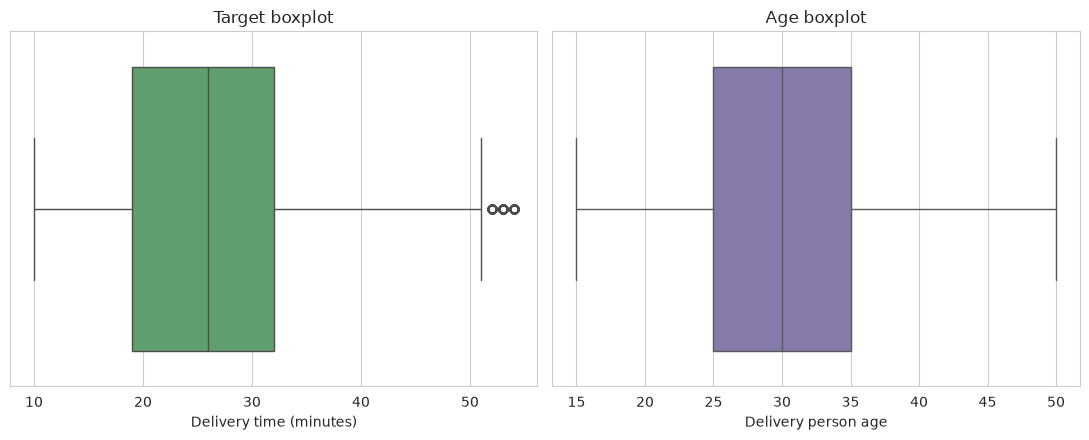

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.boxplot(x=target_preview, ax=axes[0], color='#55A868')
axes[0].set_xlabel('Delivery time (minutes)')
axes[0].set_title('Target boxplot')

sns.boxplot(x=age_preview, ax=axes[1], color='#8172B2')
axes[1].set_xlabel('Delivery person age')
axes[1].set_title('Age boxplot')
fig.tight_layout()
fig.savefig(FIG_DIR / '03_outlier_boxplots.png', dpi=120)
plt.show()

Coordinates: a meaningful chunk of rows (roughly a few thousand out of
45.6k) have restaurant coordinates outside India or parked at (0,0). Age and
ratings both look clean -- no negative ages, ratings cap out at 5. The
invalid-coordinate rows get dropped in the cleaning step since a wrong
restaurant location would corrupt the distance feature, which is the single
most important input we plan to engineer.

### 2.4 Distance, traffic, and weather vs delivery time

This is a first look only -- the haversine distance calculation gets
finalized and reused as an actual feature in step 5. Here it's just to see
whether distance is even correlated with the target before building
anything on top of it.

In [13]:
def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))

dist_preview = haversine_km(df_raw['Restaurant_latitude'], df_raw['Restaurant_longitude'],
                             df_raw['Delivery_location_latitude'], df_raw['Delivery_location_longitude'])

eda_df = pd.DataFrame({
    'distance_km': dist_preview,
    'time_taken': target_preview,
    'traffic': df_raw['Road_traffic_density'].str.strip(),
    'weather': df_raw['Weatherconditions'].str.replace('conditions ', '', regex=False).str.strip(),
})
# drop the bad-coordinate rows just for this exploratory correlation, so a
# handful of corrupted (huge) distances don't dominate the picture
valid_mask = eda_df['distance_km'].between(0.5, 50)
print('valid rows for this preview:', valid_mask.sum(), 'of', len(eda_df))
print()
print('corr(distance_km, time_taken):', eda_df.loc[valid_mask, 'distance_km'].corr(eda_df.loc[valid_mask, 'time_taken']).round(3))

valid rows for this preview: 45162 of 45593

corr(distance_km, time_taken): 0.322


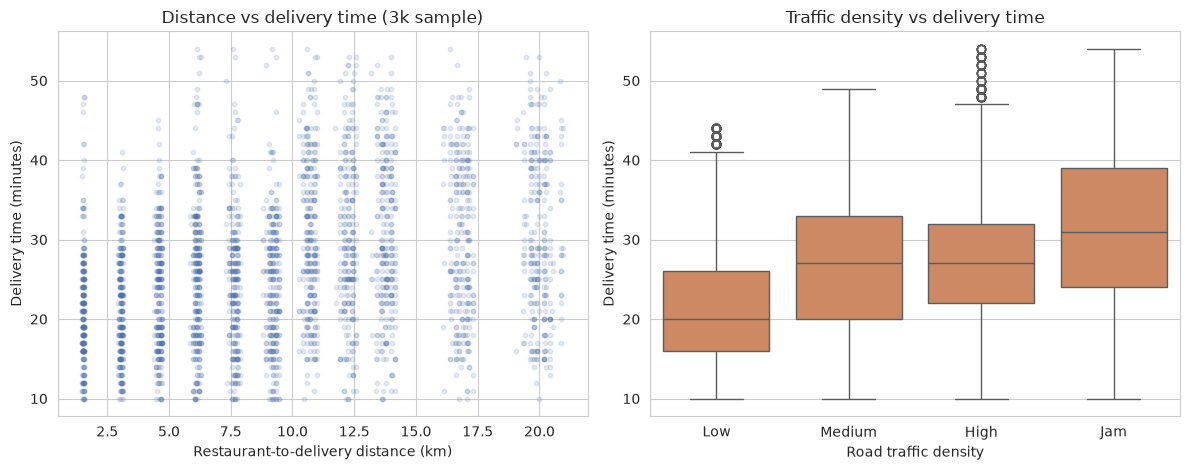

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

sample = eda_df[valid_mask].sample(3000, random_state=RANDOM_STATE)
axes[0].scatter(sample['distance_km'], sample['time_taken'], alpha=0.15, s=10, color='#4C72B0')
axes[0].set_xlabel('Restaurant-to-delivery distance (km)')
axes[0].set_ylabel('Delivery time (minutes)')
axes[0].set_title('Distance vs delivery time (3k sample)')

traffic_order = ['Low', 'Medium', 'High', 'Jam']
sns.boxplot(data=eda_df[valid_mask & eda_df['traffic'].isin(traffic_order)],
            x='traffic', y='time_taken', order=traffic_order, ax=axes[1], color='#DD8452')
axes[1].set_xlabel('Road traffic density')
axes[1].set_ylabel('Delivery time (minutes)')
axes[1].set_title('Traffic density vs delivery time')

fig.tight_layout()
fig.savefig(FIG_DIR / '04_distance_traffic_vs_time.png', dpi=120)
plt.show()

In [15]:
print(eda_df[valid_mask].groupby('weather')['time_taken'].agg(['mean', 'count']).sort_values('mean', ascending=False))

                 mean  count
weather                     
Fog         28.932667   7604
Cloudy      28.922378   7485
NaN         26.648822    467
Windy       26.127879   7382
Sandstorms  25.872481   7442
Stormy      25.866384   7544
Sunny       21.854656   7238


Distance has a real but moderate positive correlation with delivery
time -- it matters, but it's clearly not the whole story (a lot of the
spread within a fixed distance is coming from traffic/weather/vehicle/
courier factors). Traffic density shows a clean, monotonic relationship:
Jam and High traffic orders take visibly longer than Low. Weather shows
some separation too (Sunny fastest, Stormy/Sandstorms/Fog slower), though
smaller in magnitude than traffic. This is a good sign for feature
engineering -- these are exactly the signals we'd expect to matter
operationally, and they show up in the raw data before any modeling.

## 3. Cleaning

Working from `df_raw`, applying fixes in a deliberate order: strip/parse
strings first (so filters below actually work), then drop rows that can't
be trusted, then impute what's left. Every drop/impute decision is
explained inline -- this is the part most likely to come up in an
interview.

In [16]:
df = df_raw.copy()

# strip whitespace off every string column and normalize the literal 'NaN'
# marker to an actual missing value
str_cols = df.select_dtypes(include=['object', 'str']).columns
for c in str_cols:
    df[c] = df[c].str.strip()
df = df.replace('NaN', np.nan)

# weather has an extra 'conditions ' prefix baked into every value
df['Weatherconditions'] = df['Weatherconditions'].str.replace('conditions ', '', regex=False)

# target: strip '(min) ' prefix, cast to int
df['Time_taken(min)'] = df['Time_taken(min)'].str.replace('(min) ', '', regex=False).astype(int)

# numeric-looking columns that were read as strings because of the NaN marker
for c in ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print(df.shape)
df.dtypes

(45593, 20)


ID                                 str
Delivery_person_ID                 str
Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                         str
Time_Orderd                        str
Time_Order_picked                  str
Weatherconditions                  str
Road_traffic_density               str
Vehicle_condition                int64
Type_of_order                      str
Type_of_vehicle                    str
multiple_deliveries            float64
Festival                           str
City                               str
Time_taken(min)                  int64
dtype: object

### 3.1 Drop invalid coordinates

From EDA: 4,071 rows have a restaurant coordinate outside mainland India's
bounds (lat 6-38, long 68-98) or parked at/near (0, 0). A wrong restaurant
location directly corrupts distance, the single most important feature
we're about to engineer, so there's no safe way to impute this -- these
rows get dropped. Same bounds check applied to the delivery-side
coordinates too, since a bad delivery location is just as damaging.

In [17]:
def in_india_bounds(lat, lon):
    return lat.between(6, 38) & lon.between(68, 98) & ~((lat.abs() < 1) & (lon.abs() < 1))

valid_coords = (in_india_bounds(df['Restaurant_latitude'], df['Restaurant_longitude']) &
                in_india_bounds(df['Delivery_location_latitude'], df['Delivery_location_longitude']))

print('dropping', (~valid_coords).sum(), 'rows with invalid coordinates')
df = df[valid_coords].copy()
print('remaining:', len(df))

dropping 4071 rows with invalid coordinates
remaining: 41522


### 3.2 Drop invalid ratings

53 rows have `Delivery_person_Ratings` above 5 (max seen was 6.0), which is
outside the valid 1-5 star range. There's no principled value to impute --
a rating of 6 isn't "probably a 5", it's a data entry error of unknown
size -- so these rows are dropped rather than clipped.

In [18]:
bad_rating = df['Delivery_person_Ratings'] > 5
print('dropping', bad_rating.sum(), 'rows with out-of-range ratings')
df = df[~bad_rating].copy()
print('remaining:', len(df))

dropping 24 rows with out-of-range ratings
remaining: 41498


### 3.3 Drop rows with missing order time

`Time_Orderd` is missing for ~3.7% of the remaining rows. Unlike a
categorical field, a timestamp doesn't have a sensible "typical value" --
imputing a fake order time would inject noise directly into the
hour-of-day / day-of-week features we're about to build. Dropping is the
more honest choice here.

In [19]:
missing_order_time = df['Time_Orderd'].isna()
print('dropping', missing_order_time.sum(), 'rows with missing order time')
df = df[~missing_order_time].copy()
print('remaining:', len(df))

dropping 1301 rows with missing order time
remaining: 40197


### 3.4 Impute remaining missing values

What's left after the drops above is low-missingness (under 4.2%, see
EDA) and looks like random per-field reporting gaps rather than anything
tied to the target -- simple imputation is reasonable and won't
meaningfully bias the model. Numeric columns get the median (robust to
the mild skew in age/ratings); categoricals get the mode.

In [20]:
print('remaining missing values before imputation:')
print(df.isna().sum()[df.isna().sum() > 0])

remaining missing values before imputation:
Delivery_person_Age         200
Delivery_person_Ratings     239
multiple_deliveries         853
Festival                    206
City                       1056
dtype: int64


In [21]:
for c in ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']:
    fill_val = df[c].median()
    df[c] = df[c].fillna(fill_val)
    print(f'{c}: filled with median = {fill_val}')

for c in ['Road_traffic_density', 'Festival', 'City']:
    fill_val = df[c].mode()[0]
    df[c] = df[c].fillna(fill_val)
    print(f'{c}: filled with mode = {fill_val!r}')

print()
print('missing values remaining:', df.isna().sum().sum())

Delivery_person_Age: filled with median = 30.0
Delivery_person_Ratings: filled with median = 4.7
multiple_deliveries: filled with median = 1.0
Road_traffic_density: filled with mode = 'Low'
Festival: filled with mode = 'No'
City: filled with mode = 'Metropolitian'

missing values remaining: 0


In [22]:
print(f'rows: raw={len(df_raw)} -> cleaned={len(df)} ({len(df) / len(df_raw):.1%} kept)')
df[['Delivery_person_Age', 'Delivery_person_Ratings', 'Time_taken(min)']].describe()

rows: raw=45593 -> cleaned=40197 (88.2% kept)


,Delivery_person_Age,Delivery_person_Ratings,Time_taken(min)
count,40197.000000,40197.000000,40197.000000
mean,29.554594,4.634396,26.317412
std,5.747700,0.314024,9.374471
min,20.000000,2.500000,10.000000
25%,25.000000,4.500000,19.000000
50%,30.000000,4.700000,26.000000
75%,35.000000,4.900000,32.000000
max,39.000000,5.000000,54.000000


Kept about 88% of rows. That's a meaningful chunk dropped, but every
drop has a specific, defensible reason (bad geocoding, invalid rating,
unusable timestamp) rather than an arbitrary threshold -- and 40k+ rows is
still plenty for tree-based models.

## 4. Feature engineering

Building on the cleaned `df`. Each feature below has a specific reason for
being here -- listed as we go, since "why did you add this" is the natural
follow-up question for any of them.

### 4.1 Distance

Same haversine calculation used in the EDA preview, now made the actual
feature. This is the single most direct physical driver of delivery time
we have.

In [23]:
def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine_km(df['Restaurant_latitude'], df['Restaurant_longitude'],
                                  df['Delivery_location_latitude'], df['Delivery_location_longitude'])
print(df['distance_km'].describe())

count    40197.000000
mean         9.716793
std          5.598501
min          1.465067
25%          4.657655
50%          9.193021
75%         13.631449
max         20.969489
Name: distance_km, dtype: float64


### 4.2 Time-based features

`Order_Date` + `Time_Orderd` give us when the order came in. Extracting
hour of day, day of week, and a weekend flag -- delivery time in most
cities has a clear lunch/dinner rush pattern and can differ on weekends
(different traffic patterns, different order volumes).

In [24]:
order_datetime = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y')
order_time = pd.to_datetime(df['Time_Orderd'], format='%H:%M:%S')

df['order_hour'] = order_time.dt.hour
df['order_day_of_week'] = order_datetime.dt.dayofweek  # 0=Monday
df['is_weekend'] = df['order_day_of_week'].isin([5, 6]).astype(int)
df['order_date_parsed'] = order_datetime  # kept for the time-based split later, not a model feature

print('date range:', order_datetime.min().date(), 'to', order_datetime.max().date())
print()
print(df['order_hour'].value_counts().sort_index())

date range: 2022-02-11 to 2022-04-06

order_hour
0      395
8     1673
9     1779
10    1820
11    1796
12     823
13     716
14     721
15     797
16     646
17    3934
18    4118
19    4215
20    4181
21    4301
22    4176
23    4106
Name: count, dtype: int64


Clear lunch (11-12) and dinner (17-23) concentration, which matches
how food delivery demand actually works -- good sign the timestamp parsing
is correct, not an artifact.

### 4.3 Encode categoricals

`Road_traffic_density` (Low < Medium < High < Jam) is genuinely ordinal,
so it gets an ordinal encoding rather than one-hot -- this preserves the
"more traffic = more delay" ordering for the linear model instead of
throwing it away. Everything else (weather, vehicle type, order type,
city, festival) has no natural order, so those get one-hot encoded.

In [25]:
traffic_order = {'Low': 0, 'Medium': 1, 'High': 2, 'Jam': 3}
df['traffic_ordinal'] = df['Road_traffic_density'].map(traffic_order)

df['festival_flag'] = (df['Festival'] == 'Yes').astype(int)

onehot_cols = ['Weatherconditions', 'Type_of_order', 'Type_of_vehicle', 'City']
df_encoded = pd.get_dummies(df, columns=onehot_cols, prefix=['weather', 'order_type', 'vehicle', 'city'])

print('columns added by one-hot encoding:', df_encoded.shape[1] - df.shape[1])
df_encoded.filter(like='weather_').columns.tolist()

columns added by one-hot encoding: 12


['weather_Cloudy',
 'weather_Fog',
 'weather_Sandstorms',
 'weather_Stormy',
 'weather_Sunny',
 'weather_Windy']

### 4.4 Interaction feature: distance x traffic

The only interaction term added, and it's added for a specific reason
rather than "more features = better": traffic likely slows a delivery down
*proportionally* to how far the courier has to travel through it -- a jam
costs more total minutes on a 10km trip than a 1km trip. A plain linear
model can't represent that multiplicative effect from `distance_km` and
`traffic_ordinal` alone; tree models (Random Forest/XGBoost) can already
find this kind of interaction on their own by splitting on both features,
so we'd expect this engineered term to help the linear baseline more than
it helps the tree models. That's a testable claim we can check once
models are trained, not just an assumption.

In [26]:
df_encoded['distance_x_traffic'] = df_encoded['distance_km'] * df_encoded['traffic_ordinal']
df_encoded[['distance_km', 'traffic_ordinal', 'distance_x_traffic']].describe()

,distance_km,traffic_ordinal,distance_x_traffic
count,40197.000000,40197.000000,40197.000000
mean,9.716793,1.387069,14.951367
std,5.598501,1.246037,17.183538
min,1.465067,0.000000,0.000000
25%,4.657655,0.000000,0.000000
50%,9.193021,1.000000,9.363935
75%,13.631449,3.000000,23.284051
max,20.969489,3.000000,62.908468


## 5. Leakage review

The product framing for this model is: **estimate delivery time at the
moment the order is placed**, so the customer sees an ETA at checkout.
That framing decides what's fair game as a feature -- anything only known
*after* that moment is leakage, even if it's technically present in this
historical dataset.

**Excluded as leakage risk (known only after order placement, or risks
memorization instead of generalization):**

- `Time_Order_picked` -- this timestamp doesn't exist yet when the order
  is placed; it's generated once a courier physically arrives at the
  restaurant, which is itself downstream of restaurant load, courier
  availability, etc. Including it (or the order-to-pickup gap derived
  from it) would leak information from later in the delivery process
  into a prediction that's supposed to happen at the start of it.
- `Delivery_person_ID` -- a high-cardinality identifier. A tree model
  given raw IDs can effectively memorize "courier X's historical average
  delivery time," which looks like great validation performance but is
  really just recalling training rows rather than learning a
  generalizable relationship, and it would break entirely for a courier
  the model hasn't seen before. (A legitimate version of this idea --
  a courier's *historical, time-windowed* average speed as an aggregated
  feature -- would need careful expanding-window construction so it never
  sees a courier's future deliveries. Left as a future improvement, not
  attempted here to keep scope tight.)

**Excluded for redundancy/generalization, not leakage:**

- `ID` -- pure row identifier, no predictive content.
- Raw `Order_Date` / `Time_Orderd` strings -- superseded by the derived
  `order_hour` / `order_day_of_week` / `is_weekend` features. Keeping the
  raw strings as high-cardinality categoricals adds nothing on top of
  the derived features and only risks overfitting to specific
  date/time strings.
- Raw restaurant/delivery latitude and longitude -- superseded by
  `distance_km`. Keeping exact coordinates risks the model fitting to
  specific coordinate clusters seen in training rather than learning
  the general distance/traffic relationship, and wouldn't generalize to
  a new city. `City` is kept as a coarser geographic signal instead.

**Kept, and why they're safe:** distance, order time features, traffic,
weather, vehicle type/condition, order type, delivery person age/rating,
multiple_deliveries, festival flag -- all of these are known (or are a
reasonable forecast/default, e.g. current traffic and weather conditions)
at the moment an order is placed.

In [27]:
excluded_cols = [
    'ID', 'Delivery_person_ID', 'Time_Order_picked', 'Order_Date', 'Time_Orderd',
    'Restaurant_latitude', 'Restaurant_longitude',
    'Delivery_location_latitude', 'Delivery_location_longitude',
    'Road_traffic_density', 'Festival',  # replaced by encoded versions
]
target_col = 'Time_taken(min)'

feature_cols = [c for c in df_encoded.columns if c not in excluded_cols + [target_col, 'order_date_parsed']]

# sanity check: none of the excluded/leakage-risk columns made it into the feature set
assert not set(excluded_cols) & set(feature_cols), 'a leakage-risk column leaked into features!'
print(f'{len(feature_cols)} features going into modeling:')
print(feature_cols)

27 features going into modeling:
['Delivery_person_Age', 'Delivery_person_Ratings', 'Vehicle_condition', 'multiple_deliveries', 'distance_km', 'order_hour', 'order_day_of_week', 'is_weekend', 'traffic_ordinal', 'festival_flag', 'weather_Cloudy', 'weather_Fog', 'weather_Sandstorms', 'weather_Stormy', 'weather_Sunny', 'weather_Windy', 'order_type_Buffet', 'order_type_Drinks', 'order_type_Meal', 'order_type_Snack', 'vehicle_electric_scooter', 'vehicle_motorcycle', 'vehicle_scooter', 'city_Metropolitian', 'city_Semi-Urban', 'city_Urban', 'distance_x_traffic']


## 6. Train/test split

Using a **time-based split** rather than a random shuffle: orders span
2022-02-11 to 2022-04-06 (about 8 weeks), which is enough range to hold
out the most recent slice as a test set. This mirrors how the model would
actually be deployed -- trained on past orders, evaluated on orders that
happened after training data ends -- and avoids the split leaking
information a random shuffle wouldn't catch (e.g. if delivery patterns
drift over the data collection window, a random split would let the
model "see the future" during training in a way it never could in
production).

In [28]:
split_date = df_encoded['order_date_parsed'].quantile(0.8)
print('split date (80th percentile):', split_date.date())

train_mask = df_encoded['order_date_parsed'] < split_date
test_mask = ~train_mask

train_df = df_encoded[train_mask].copy()
test_df = df_encoded[test_mask].copy()

print(f'train: {len(train_df)} rows ({train_df["order_date_parsed"].min().date()} to {train_df["order_date_parsed"].max().date()})')
print(f'test:  {len(test_df)} rows ({test_df["order_date_parsed"].min().date()} to {test_df["order_date_parsed"].max().date()})')
print(f'test share: {len(test_df) / len(df_encoded):.1%}')

split date (80th percentile): 2022-03-29


train: 31672 rows (2022-02-11 to 2022-03-28)
test:  8525 rows (2022-03-29 to 2022-04-06)
test share: 21.2%


In [29]:
X_train, y_train = train_df[feature_cols], train_df[target_col]
X_test, y_test = test_df[feature_cols], test_df[target_col]

print(X_train.shape, X_test.shape)
print()
print('train target mean:', round(y_train.mean(), 2), '| test target mean:', round(y_test.mean(), 2))

(31672, 27) (8525, 27)

train target mean: 26.25 | test target mean: 26.59


Train/test target means are close (both in the mid-20s), so there's no
obvious distribution shift between the two periods that would make this an
unfair comparison -- good, means the held-out period is a reasonable stand-in
for "the near future" rather than some structurally different regime.

## 7. Baseline: Linear Regression

Starting with the simplest reasonable model. The point of a linear
baseline isn't to win -- it's to have an honest floor: if a Random Forest
or XGBoost can't beat this by a meaningful margin, that's a sign the extra
complexity isn't buying anything, and it's the number every fancier model
gets compared against.

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

pred_lin = lin_reg.predict(X_test_scaled)

def report_metrics(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    print(f'{label}: MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.3f}')
    return {'model': label, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []
results.append(report_metrics(y_test, pred_lin, 'Linear Regression'))

Linear Regression: MAE=4.779  RMSE=5.981  R2=0.605


### Sanity check: is the linear baseline believable?

Delivery time realistically depends on plenty we don't have (courier's
exact route, real-time GPS speed, restaurant prep queue length at that
exact minute), so an R2 in the 0.4-0.6 range would be expected for a model
using only order-time metadata -- not close to 1.0. Checking that now,
before comparing anything else against it.

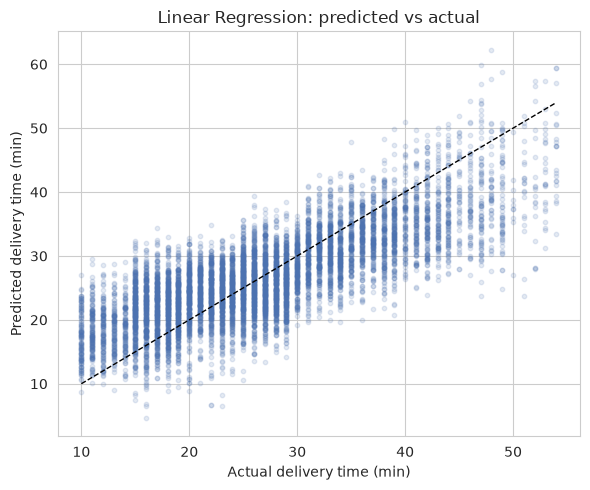

In [31]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, pred_lin, alpha=0.15, s=10, color='#4C72B0')
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Actual delivery time (min)')
ax.set_ylabel('Predicted delivery time (min)')
ax.set_title('Linear Regression: predicted vs actual')
fig.tight_layout()
plt.show()

## 8. Model comparison: Random Forest and XGBoost

Tree models get the raw (unscaled) features -- no need for standardization
since splits are scale-invariant. Light tuning only: a small grid over the
2-3 hyperparameters that actually matter for each model, 3-fold CV on the
training set. This is a case study, not a leaderboard push -- spent under
30 minutes total on tuning both models.

In [32]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 12, None],
}

rf_search = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1,
)
rf_search.fit(X_train, y_train)

print('best RF params:', rf_search.best_params_)
print('best RF CV MAE:', -rf_search.best_score_)

rf_model = rf_search.best_estimator_
pred_rf = rf_model.predict(X_test)
results.append(report_metrics(y_test, pred_rf, 'Random Forest'))

best RF params: {'max_depth': 12, 'n_estimators': 200}
best RF CV MAE: 3.0417712110365844
Random Forest: MAE=3.097  RMSE=3.802  R2=0.840


In [33]:
from xgboost import XGBRegressor

xgb_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
}

xgb_search = GridSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, objective='reg:squarederror'),
    xgb_param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1,
)
xgb_search.fit(X_train, y_train)

print('best XGB params:', xgb_search.best_params_)
print('best XGB CV MAE:', -xgb_search.best_score_)

xgb_model = xgb_search.best_estimator_
pred_xgb = xgb_model.predict(X_test)
results.append(report_metrics(y_test, pred_xgb, 'XGBoost'))

best XGB params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 400}
best XGB CV MAE: 3.0685342947642007
XGBoost: MAE=3.126  RMSE=3.863  R2=0.835


### Checking the distance x traffic hypothesis from feature engineering

Earlier claim: the `distance_x_traffic` interaction term should help
Linear Regression more than the tree models, since trees can already
approximate that interaction by splitting on both features. Quick check:
refit linear regression without it and compare.

In [34]:
no_interaction_cols = [c for c in feature_cols if c != 'distance_x_traffic']
X_train_no_int = scaler.fit_transform(train_df[no_interaction_cols])
X_test_no_int = scaler.transform(test_df[no_interaction_cols])

lin_no_int = LinearRegression().fit(X_train_no_int, y_train)
pred_no_int = lin_no_int.predict(X_test_no_int)
_ = report_metrics(y_test, pred_no_int, 'Linear Regression (no interaction term)')
print(f"with interaction term: MAE={results[0]['MAE']:.3f}")

Linear Regression (no interaction term): MAE=4.782  RMSE=5.986  R2=0.604
with interaction term: MAE=4.779
